In [23]:
# Predicting Life 

Advances in medicine, the expansion of healthcare facilities, 
and improved standards of care have all contributed to a rise in average life expectancy over the past few decades.
While this may seem like a tremendous achievement for humanity, it has also led to an increasing number 
of older adults being placed in assisted living communities. The ethics, benefits, 
and drawbacks of sending parents to such facilities remain controversial; however, 
this practice has placed a significant financial burden on both the private and government sectors.

In this Lab, you will use a subset of the life expectancy dataset from the National Center for Health Statistics 
of the Centers for Disease Control and Prevention. The site hosts numerous open datasets on topics 
such as injuries, poverty, women s health, education, health insurance, and, of course, infectious diseases. 
But the one you ll be using is the "Average Lifespan by Sex, Race" dataset, 
which contains statistics collected in the United States from the 1900s to the present. 
We ve included a copy of this dataset as **[life_expectancy.csv]**. 
The dataset only lists lifespan for white and black people because, 
for most of the time it was collected, those were the two major races for which statistics were recorded in the United States.

SyntaxError: unterminated string literal (detected at line 13) (1989911708.py, line 13)

In [22]:
# import libraries 
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

matplotlib.style.use('ggplot') # Look Pretty

In [2]:
# Create a function
def drawLine(model, X_test, y_test, title):
    fig = plt.figure()
    ax = fig.add_subplot(111)
    ax.scatter(X_test, y_test, c='g', marker='o')
    ax.plot(X_test, model.predict(X_test), color='orange', linewidth=1, alpha=0.7)

    print("Est 2014 " + title + " Life Expectancy: ", model.predict([[2014]])[0])
    print("Est 2030 " + title + " Life Expectancy: ", model.predict([[2030]])[0])
    print("Est 2045 " + title + " Life Expectancy: ", model.predict([[2045]])[0])

    score = model.score(X_test, y_test)
    title += " R2: " + str(score)
    ax.set_title(title)

    plt.show()

In [3]:
# Prepare the data
x = pd.read_csv('life_expectancy.csv', sep='\t')
x.describe()
x.head()

,Year,WhiteMale,WhiteFemale,BlackMale,BlackFemale
0,1900,46.6,48.7,32.5,33.5
1,1950,66.5,72.2,59.1,62.9
2,1960,67.4,74.1,61.1,66.3
3,1970,68.0,75.6,60.0,68.3
4,1975,69.5,77.3,62.4,71.3


In [5]:
# Create a linear regression model and store it in 'model.'

from sklearn.linear_model import LinearRegression
model = LinearRegression()


In [14]:
# Splitting data

print(x[['WhiteMale']].head())
print(x.dtypes)

# Create a boolean for years less than 1986
year_less_than_1986 = x['Year'] < 1986

# Select 'Year' values for training (x_train)
x_train = x.loc[year_less_than_1986,['Year']]

# Select 'WhiteMale' values for training label (y_train)
y_train = x.loc[year_less_than_1986,['WhiteMale']]

print(x_train.head())
print(y_train.head())



   WhiteMale
0       46.6
1       66.5
2       67.4
3       68.0
4       69.5
Year             int64
WhiteMale      float64
WhiteFemale    float64
BlackMale      float64
BlackFemale    float64
dtype: object
   Year
0  1900
1  1950
2  1960
3  1970
4  1975
   WhiteMale
0       46.6
1       66.5
2       67.4
3       68.0
4       69.5


Est 2014 WhiteMale Life Expectancy:  [80.85635426]
Est 2030 WhiteMale Life Expectancy:  [85.39349384]
Est 2045 WhiteMale Life Expectancy:  [89.6470622]


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


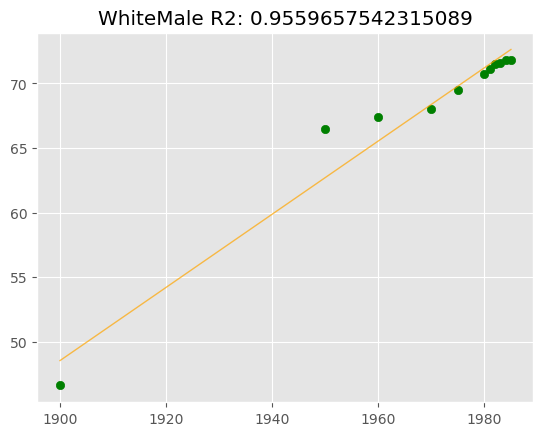

In [16]:
#Train the model and then pass it to 'drawLine' with the training set and labels.
model.fit(x_train,y_train)

drawLine(model,x_train,y_train,'WhiteMale')

In [17]:
# Print the actual lifespan of 'WhiteMale' 2014 from the downloaded dataset.

print("Actual 2014 WhiteMale Life Expectancy: ", x.loc[x['Year'] == 2014, 'WhiteMale'].values[0])


Actual 2014 WhiteMale Life Expectancy:  76.7


In [18]:
# Print a correlation matrix for the entire dataset and display a visual representation of the correlation matrix.

import seaborn as sns

correlation_matrix = x.corr(numeric_only=True)
print("correlation matrix :")
print(correlation_matrix)

correlation matrix :
                 Year  WhiteMale  WhiteFemale  BlackMale  BlackFemale
Year         1.000000   0.974154     0.913907   0.960635     0.940429
WhiteMale    0.974154   1.000000     0.975164   0.987974     0.985009
WhiteFemale  0.913907   0.975164     1.000000   0.956689     0.994656
BlackMale    0.960635   0.987974     0.956689   1.000000     0.975922
BlackFemale  0.940429   0.985009     0.994656   0.975922     1.000000


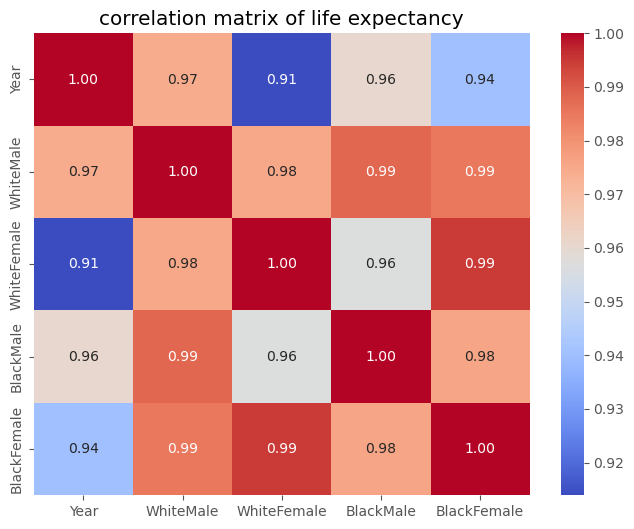

In [19]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('correlation matrix of life expectancy')
plt.show()